# Tilt-distance census: publication dashboard gallery

Ten alternative **full-page, multi-panel dashboards** for presenting the tilt-distance census. Every comparison separates anticyclonic (AE) and cyclonic (CE) eddies. Direction is intentionally left for later analysis.

Following the regional interpretation used here, the upstream sector contains **S1, U1 and U2**, while the downstream sector contains **S2, D1 and D2**. Daily distributions use equal total weight per eddy; per-eddy summaries contain one value per eddy.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import seacofs_tilt_tools as tilt

AE_COLOUR = '#C4473A'
CE_COLOUR = '#247BA0'
TYPE_COLOURS = {'AE': AE_COLOUR, 'CE': CE_COLOUR}
SUBREGION_ORDER = ['S1','U1','U2','S2','D1','D2']
SECTOR_ORDER = ['Upstream + S1','Downstream + S2']
SECTOR_MAP = {'S1':'Upstream + S1','U1':'Upstream + S1','U2':'Upstream + S1',
              'S2':'Downstream + S2','D1':'Downstream + S2','D2':'Downstream + S2'}
SAVE_FIGURES = False
FIGURE_DIR = Path('tilt_census_dashboards')
PAGE_SIZE = (11.7, 8.3)

mpl.rcParams.update({'figure.dpi':120,'savefig.dpi':600,'font.size':9,
 'axes.titlesize':10,'axes.labelsize':9,'legend.fontsize':8,
 'axes.spines.top':False,'axes.spines.right':False,
 'pdf.fonttype':42,'ps.fonttype':42})

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
df_eddies = df_eddies.sort_values(['Cyc','Eddy','Day']).copy()
df_eddies['Sector'] = df_eddies['Region'].map(SECTOR_MAP)
KEYS = ['Cyc','Eddy']
df_eddies['day_index'] = df_eddies.groupby(KEYS).cumcount()
last_index = df_eddies.groupby(KEYS)['day_index'].transform('max')
df_eddies['norm_time'] = np.where(last_index>0, df_eddies.day_index/last_index, np.nan)
df_eddies['lifetime_days'] = df_eddies.groupby(KEYS)['Day'].transform(lambda x:x.max()-x.min()+1)
tilt_data = df_eddies.dropna(subset=['TiltDis']).query("Cyc in ['AE','CE']").copy()
TILT_LIMIT = float(tilt_data.TiltDis.quantile(.995))
TILT_BINS = np.linspace(0, TILT_LIMIT, 42)

display(pd.DataFrame({'Tilt observations':tilt_data.groupby('Cyc').size(),
                      'Eddies represented':tilt_data.groupby('Cyc').Eddy.nunique(),
                      'Median tilt (km)':tilt_data.groupby('Cyc').TiltDis.median()}).round(2))

,Tilt observations,Eddies represented,Median tilt (km)
Cyc,,,
AE,53607,1422,19.61
CE,52014,1531,16.01


In [2]:
def panel_label(ax, label):
    ax.text(-.11,1.05,label,transform=ax.transAxes,fontsize=11,fontweight='bold')

def finish_dashboard(fig, name, title):
    fig.suptitle(title,fontsize=15,fontweight='bold',y=.995)
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(exist_ok=True)
        fig.savefig(FIGURE_DIR/f'{name}.pdf',bbox_inches='tight')
        fig.savefig(FIGURE_DIR/f'{name}.png',bbox_inches='tight',dpi=600)
    plt.show()

def equal_eddy_weights(data):
    return 1/data.groupby(KEYS)['Eddy'].transform('size').astype(float)

def eddy_metrics(data):
    def summarise(g):
        x=g.TiltDis.dropna().to_numpy()
        return pd.Series({'mean':np.mean(x),'median':np.median(x),'minimum':np.min(x),
          'maximum':np.max(x),'range':np.ptp(x),'std':np.std(x,ddof=1) if len(x)>1 else np.nan,
          'p90':np.quantile(x,.9),'n_tilt':len(x),'lifetime_days':g.lifetime_days.max(),
          'Sector':g.Sector.mode().iat[0] if g.Sector.notna().any() else np.nan})
    return data.groupby(KEYS).apply(summarise,include_groups=False).reset_index()

def mirrored_hist(ax, data, column='TiltDis', bins=None, title='', xlabel='Tilt distance (km)', daily=False):
    arrays={}; weights={}
    for cyc in ['AE','CE']:
        g=data[data.Cyc==cyc].dropna(subset=[column])
        arrays[cyc]=g[column].to_numpy()
        weights[cyc]=(equal_eddy_weights(g).to_numpy() if daily else np.ones(len(g)))
    all_values=np.concatenate([v for v in arrays.values() if len(v)])
    if bins is None:
        hi=np.nanquantile(all_values,.99); bins=np.linspace(0,hi,34)
    for cyc,sign in [('AE',1),('CE',-1)]:
        h,e=np.histogram(arrays[cyc],bins=bins,weights=weights[cyc])
        h=h/h.sum()*100 if h.sum() else h
        ax.stairs(sign*h,e,fill=True,alpha=.45,color=TYPE_COLOURS[cyc],label=cyc)
        ax.stairs(sign*h,e,lw=1.3,color=TYPE_COLOURS[cyc])
        if len(arrays[cyc]):
            med=np.median(arrays[cyc]); ax.axvline(med,color=TYPE_COLOURS[cyc],ls='--',lw=1)
    ax.axhline(0,color='.25',lw=.7); ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_:f'{abs(y):g}'))
    ax.set(title=title,xlabel=xlabel,ylabel='Probability (%)'); ax.grid(axis='x',alpha=.15)
    return ax

def metric_dashboard(data, title, name):
    em=eddy_metrics(data); specs=[
      ('TiltDis','All tilt observations','Tilt distance (km)',True),
      ('mean','Mean tilt per eddy','Mean tilt (km)',False),
      ('median','Median tilt per eddy','Median tilt (km)',False),
      ('minimum','Minimum tilt per eddy','Minimum tilt (km)',False),
      ('maximum','Maximum tilt per eddy','Maximum tilt (km)',False),
      ('range','Within-eddy tilt range','Maximum − minimum (km)',False)]
    fig,axes=plt.subplots(2,3,figsize=PAGE_SIZE,constrained_layout=True)
    for i,(ax,(col,ttl,xlab,daily)) in enumerate(zip(axes.flat,specs)):
        source=data if daily else em; mirrored_hist(ax,source,col,TILT_BINS if daily else None,ttl,xlab,daily)
        panel_label(ax,chr(97+i))
    axes[0,0].legend(frameon=False,ncol=2); finish_dashboard(fig,name,title)

def weighted_ecdf(g):
    x=g.TiltDis.to_numpy(); w=equal_eddy_weights(g).to_numpy(); order=np.argsort(x)
    return x[order],np.cumsum(w[order])/w.sum()

def grouped_quantiles(data, group):
    return data.groupby(['Cyc',group]).TiltDis.quantile([.1,.25,.5,.75,.9]).unstack().reset_index()


## Dashboard 1 — Complete tilt-distance census
The closest successor to the original notebook: daily tilt and five complementary per-eddy summaries.

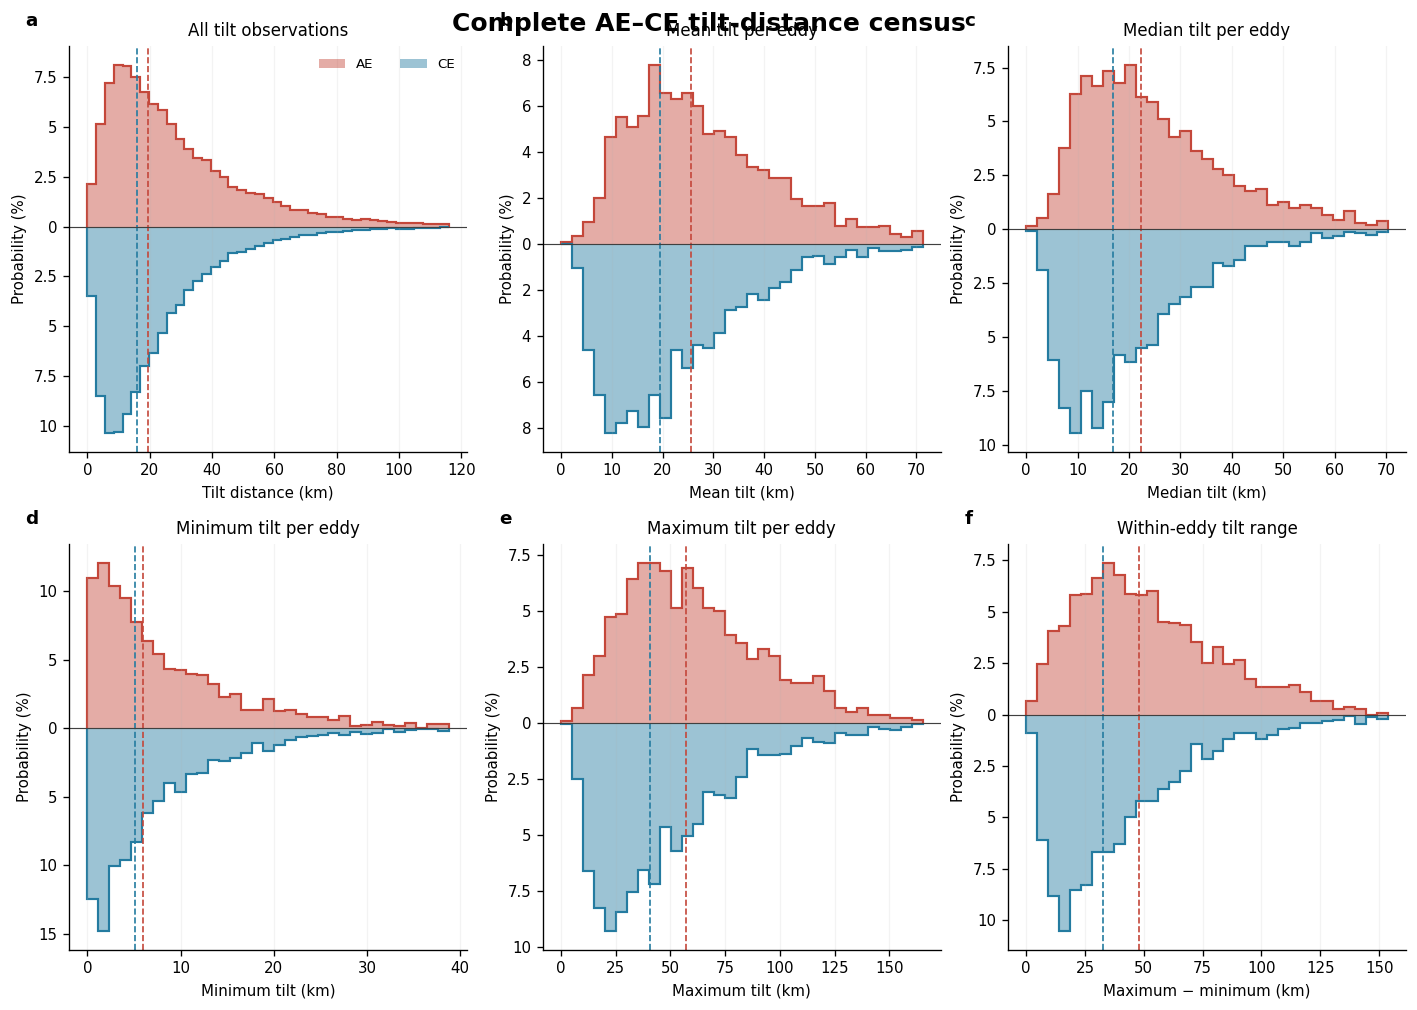

In [3]:
metric_dashboard(tilt_data,'Complete AE–CE tilt-distance census','01_complete_census')

## Dashboard 2 — Upstream sector census
Restricted to S1, U1 and U2.

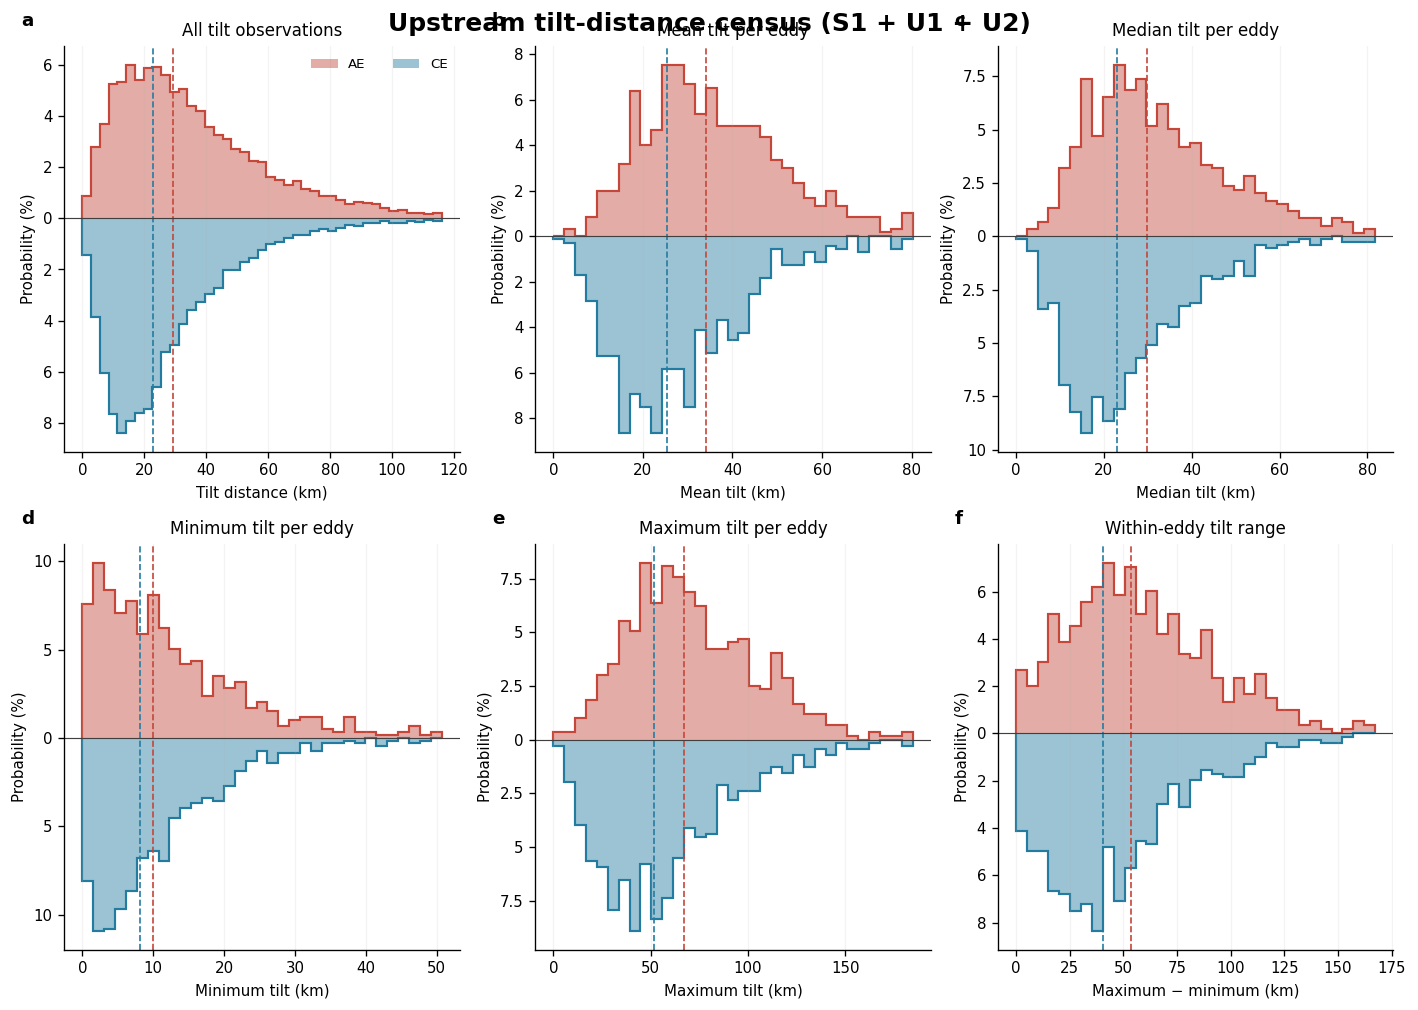

In [4]:
upstream=tilt_data[tilt_data.Sector=='Upstream + S1'].copy()
metric_dashboard(upstream,'Upstream tilt-distance census (S1 + U1 + U2)','02_upstream_census')

## Dashboard 3 — Downstream sector census
Restricted to S2, D1 and D2.

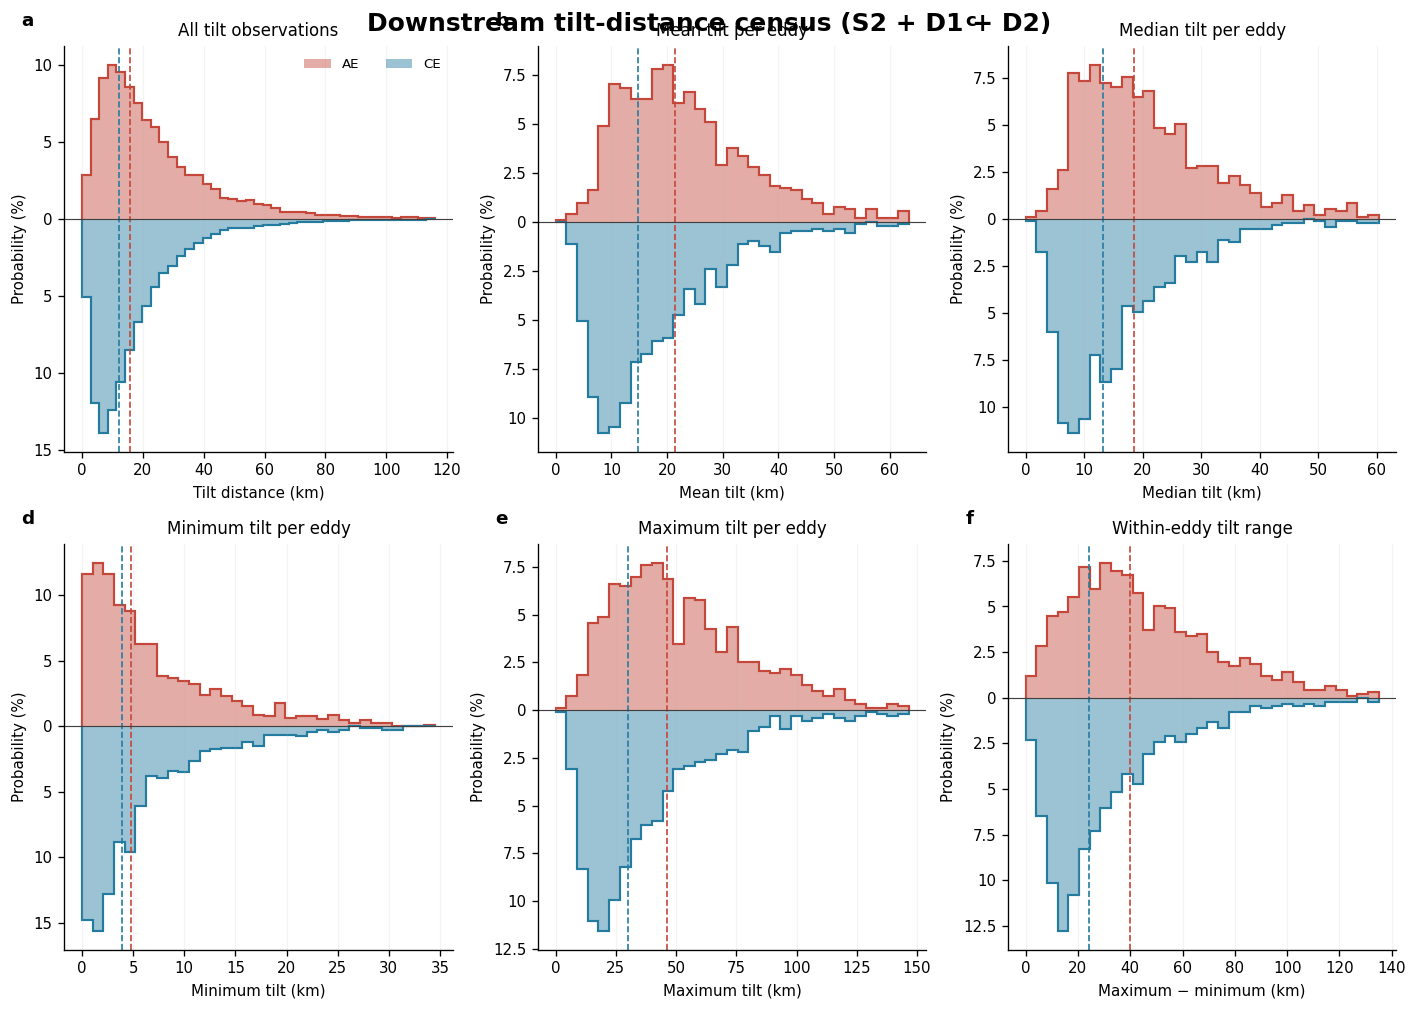

In [5]:
downstream=tilt_data[tilt_data.Sector=='Downstream + S2'].copy()
metric_dashboard(downstream,'Downstream tilt-distance census (S2 + D1 + D2)','03_downstream_census')

## Dashboard 4 — Upstream versus downstream
Each column is a sector; rows move from observations to eddy-typical and extreme tilt.

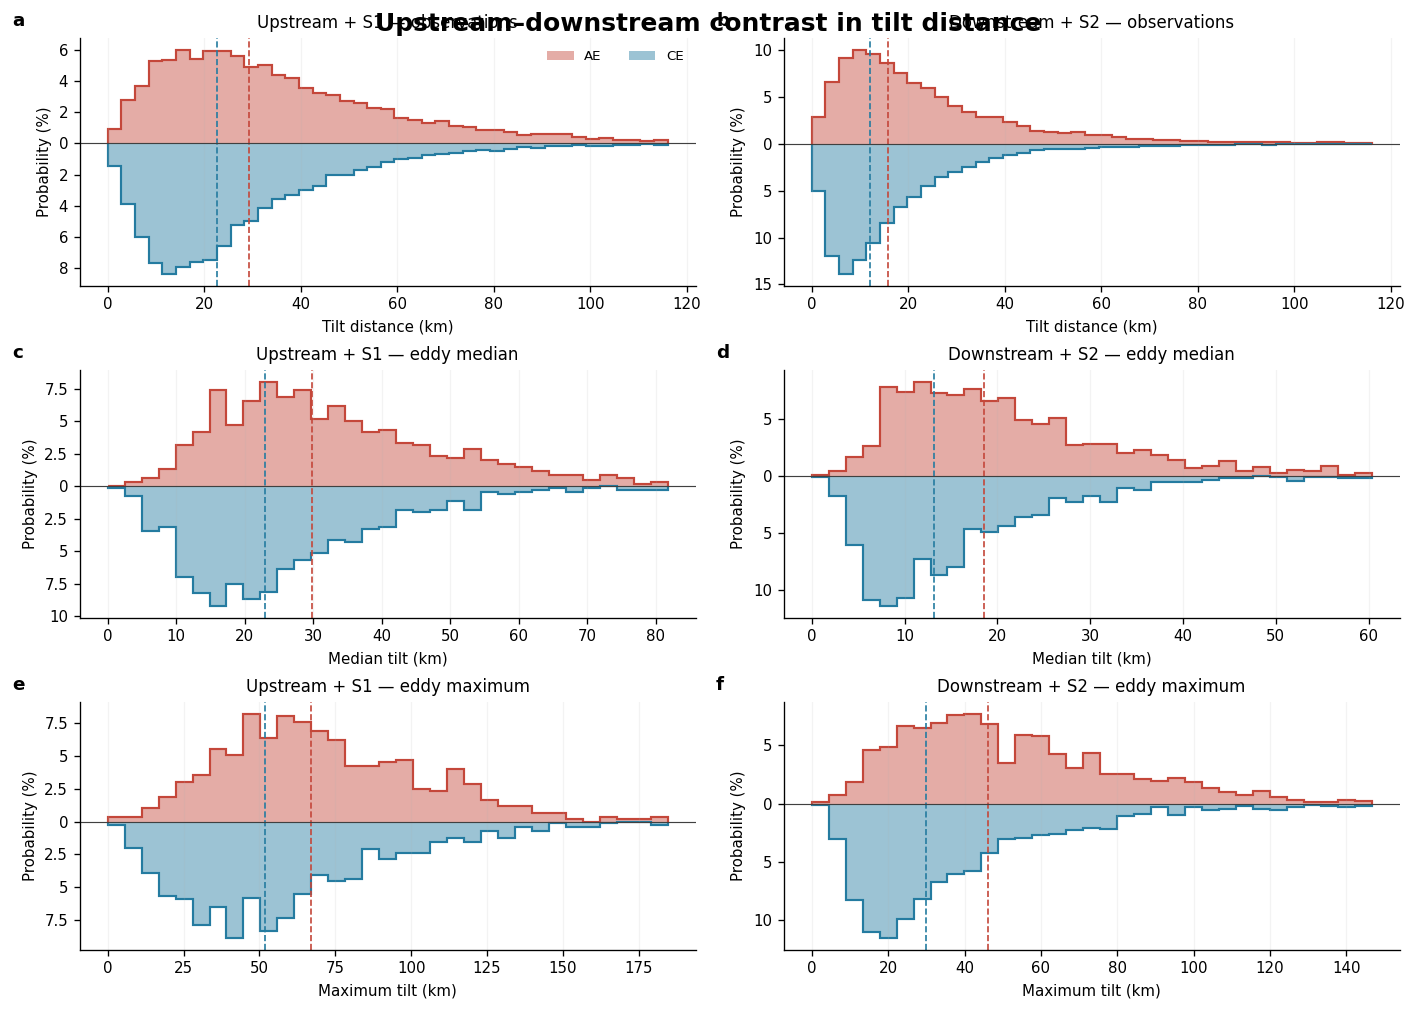

In [6]:
fig,axes=plt.subplots(3,2,figsize=PAGE_SIZE,constrained_layout=True)
for j,(sector,subset) in enumerate([('Upstream + S1',upstream),('Downstream + S2',downstream)]):
    em=eddy_metrics(subset)
    mirrored_hist(axes[0,j],subset,'TiltDis',TILT_BINS,sector+' — observations','Tilt distance (km)',True)
    mirrored_hist(axes[1,j],em,'median',None,sector+' — eddy median','Median tilt (km)')
    mirrored_hist(axes[2,j],em,'maximum',None,sector+' — eddy maximum','Maximum tilt (km)')
for i,ax in enumerate(axes.flat): panel_label(ax,chr(97+i))
axes[0,0].legend(frameon=False,ncol=2); finish_dashboard(fig,'04_sector_comparison','Upstream–downstream contrast in tilt distance')

## Dashboard 5 — Six-region tilt atlas
One mirrored daily tilt distribution for every constituent region.

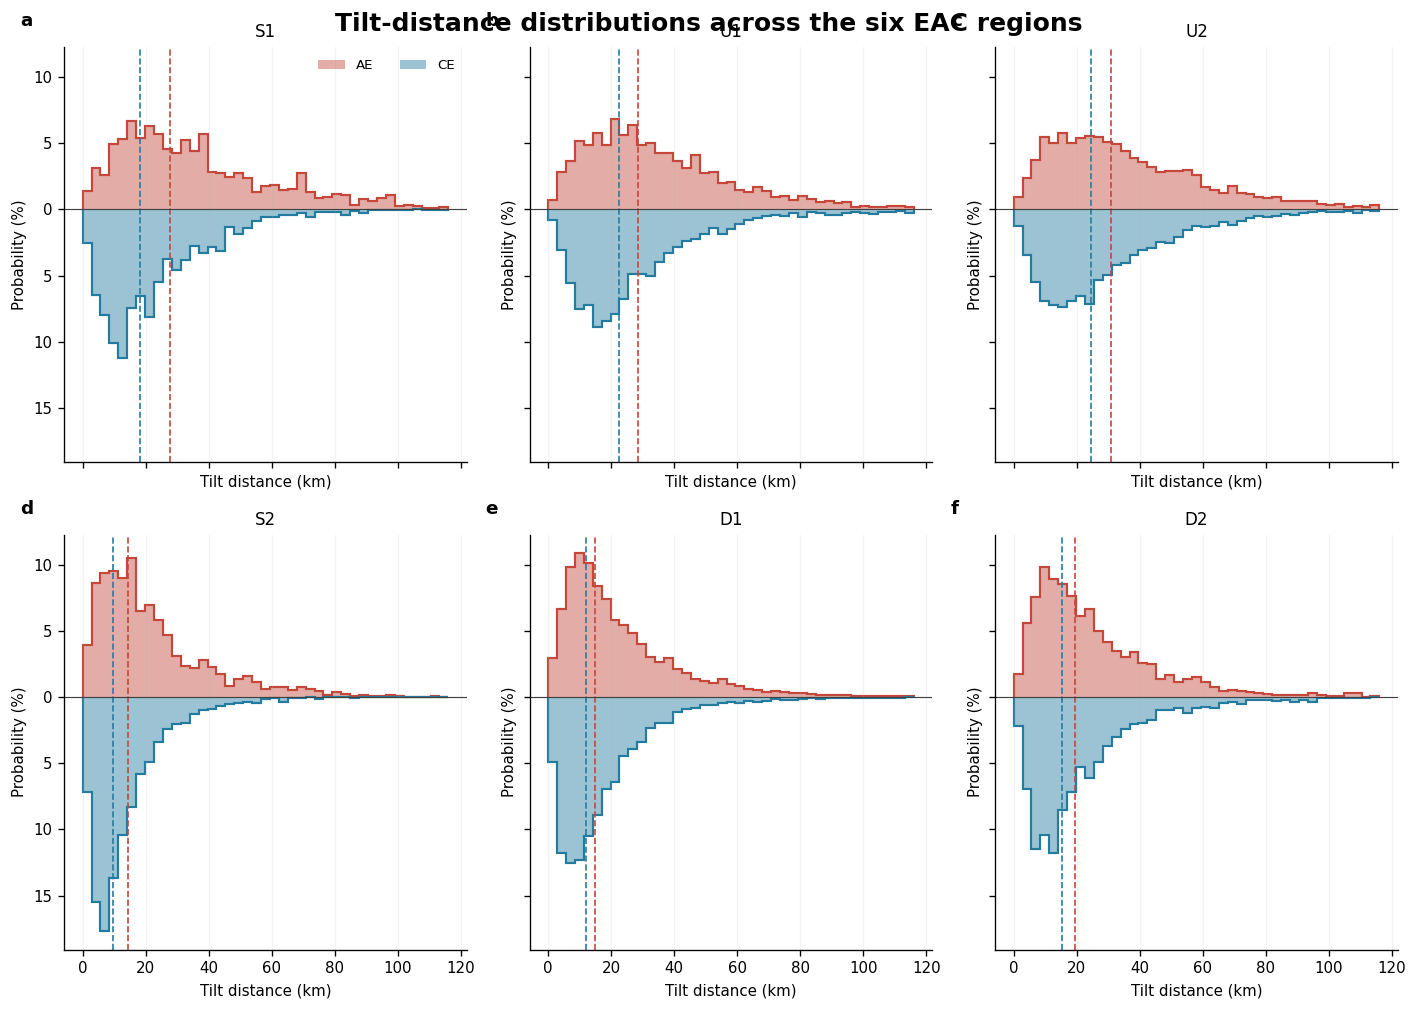

In [7]:
fig,axes=plt.subplots(2,3,figsize=PAGE_SIZE,sharex=True,sharey=True,constrained_layout=True)
for i,(ax,region) in enumerate(zip(axes.flat,SUBREGION_ORDER)):
    g=tilt_data[tilt_data.Region==region]
    mirrored_hist(ax,g,'TiltDis',TILT_BINS,region,'Tilt distance (km)',True); panel_label(ax,chr(97+i))
axes[0,0].legend(frameon=False,ncol=2); finish_dashboard(fig,'05_six_region_atlas','Tilt-distance distributions across the six EAC regions')

## Dashboard 6 — Lifetime-class census
Short-, intermediate- and long-lived classes are eddy-level terciles calculated separately for AE and CE.

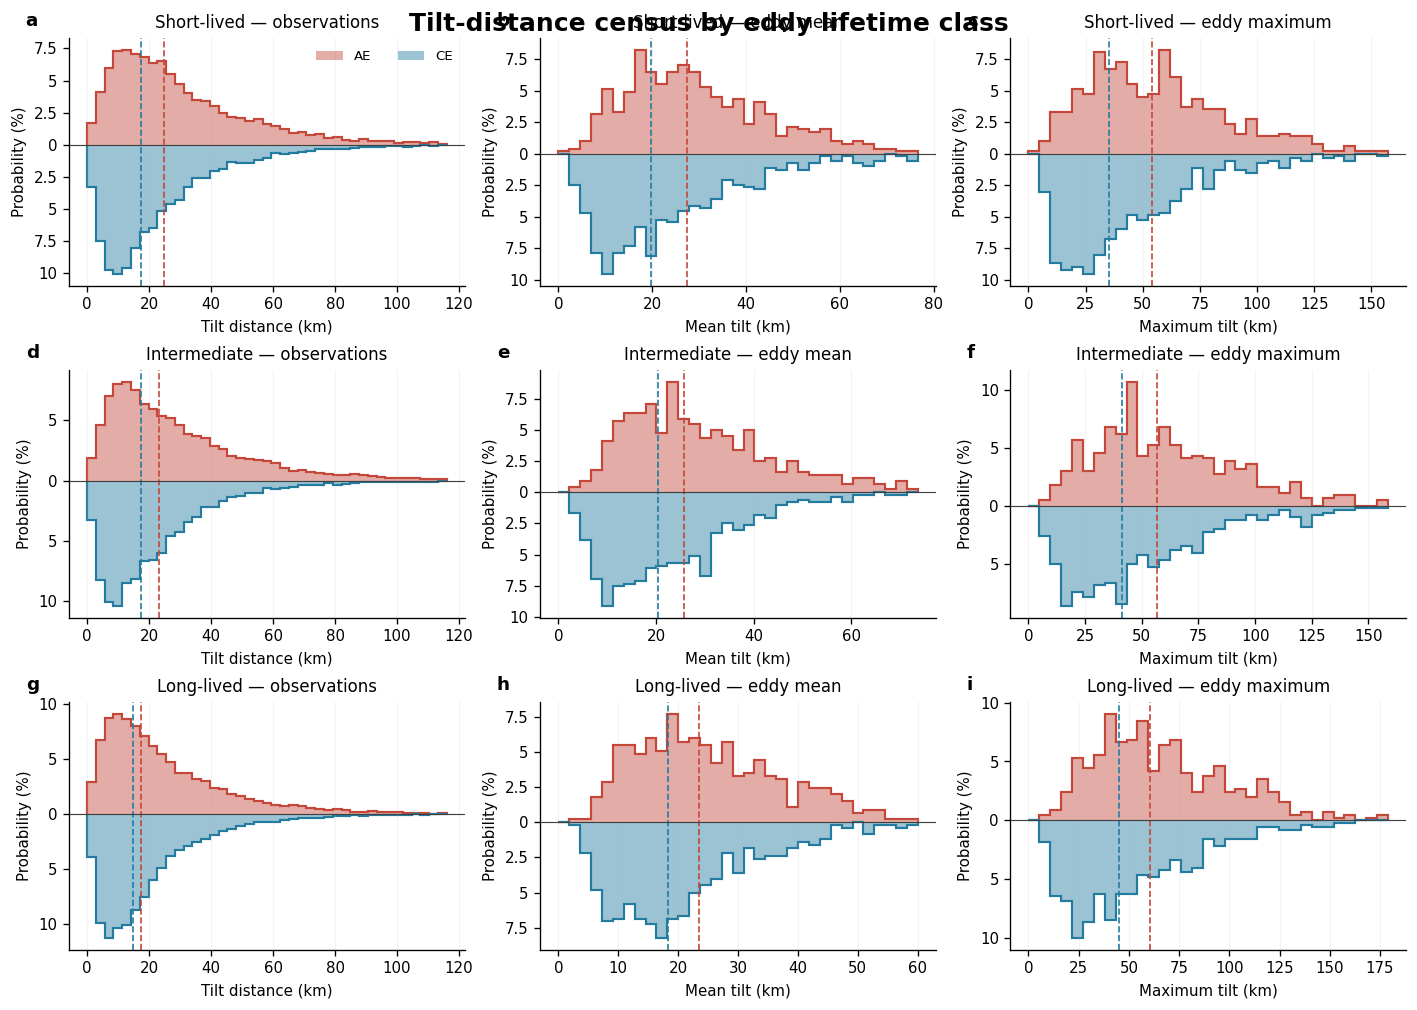

In [8]:
eddy_life=tilt_data.groupby(KEYS,as_index=False).lifetime_days.max(); class_frames=[]
LIFE_LABELS=['Short-lived','Intermediate','Long-lived']
for cyc,g in eddy_life.groupby('Cyc'):
    q1,q2=g.lifetime_days.quantile([1/3,2/3]); g=g.copy()
    g['LifetimeClass']=pd.cut(g.lifetime_days,[-np.inf,q1,q2,np.inf],labels=LIFE_LABELS); class_frames.append(g)
life_map=pd.concat(class_frames); life_data=tilt_data.merge(life_map,on=KEYS+['lifetime_days'],how='left')
fig,axes=plt.subplots(3,3,figsize=PAGE_SIZE,constrained_layout=True)
for i,cls in enumerate(LIFE_LABELS):
    g=life_data[life_data.LifetimeClass==cls]; em=eddy_metrics(g)
    mirrored_hist(axes[i,0],g,'TiltDis',TILT_BINS,cls+' — observations','Tilt distance (km)',True)
    mirrored_hist(axes[i,1],em,'mean',None,cls+' — eddy mean','Mean tilt (km)')
    mirrored_hist(axes[i,2],em,'maximum',None,cls+' — eddy maximum','Maximum tilt (km)')
for i,ax in enumerate(axes.flat): panel_label(ax,chr(97+i))
axes[0,0].legend(frameon=False,ncol=2); finish_dashboard(fig,'06_lifetime_classes','Tilt-distance census by eddy lifetime class')

## Dashboard 7 — Lifecycle-stage census
Early, middle and late thirds of normalised eddy lifetime, shown overall and within both sectors.

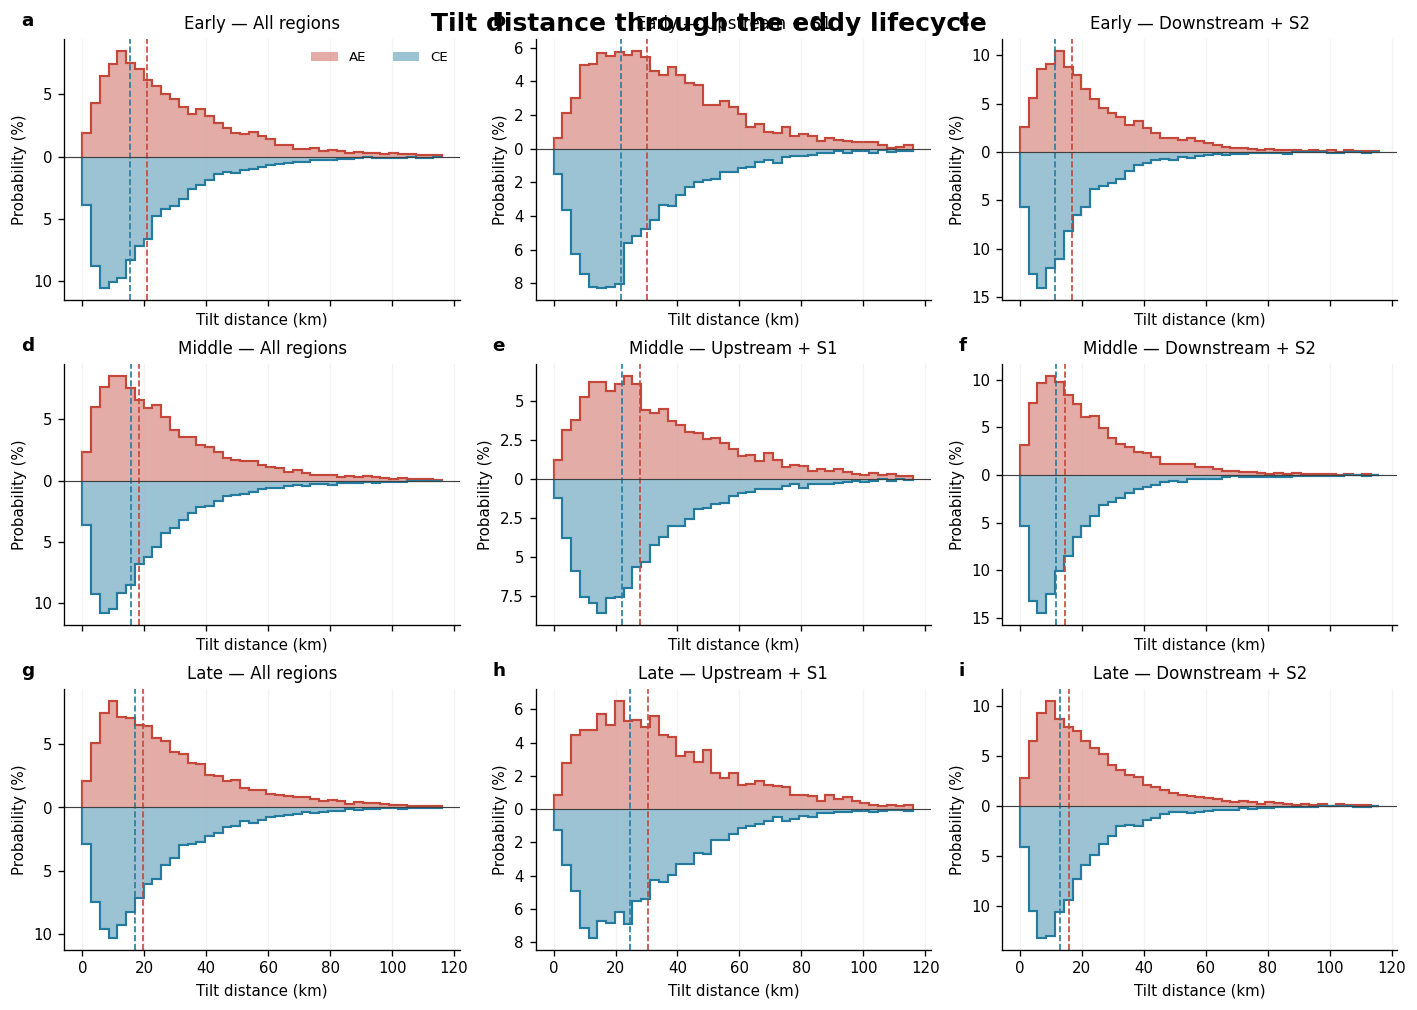

In [9]:
stage_data=tilt_data.copy(); stage_data['Stage']=pd.cut(stage_data.norm_time,[-.001,1/3,2/3,1.001],labels=['Early','Middle','Late'])
fig,axes=plt.subplots(3,3,figsize=PAGE_SIZE,sharex=True,constrained_layout=True)
columns=[('All regions',None),('Upstream + S1','Upstream + S1'),('Downstream + S2','Downstream + S2')]
for i,stage in enumerate(['Early','Middle','Late']):
    for j,(label,sector) in enumerate(columns):
        g=stage_data[stage_data.Stage==stage]
        if sector is not None: g=g[g.Sector==sector]
        mirrored_hist(axes[i,j],g,'TiltDis',TILT_BINS,f'{stage} — {label}','Tilt distance (km)',True)
for i,ax in enumerate(axes.flat): panel_label(ax,chr(97+i))
axes[0,0].legend(frameon=False,ncol=2); finish_dashboard(fig,'07_lifecycle_stages','Tilt distance through the eddy lifecycle')

## Dashboard 8 — Extreme-tilt census
Exceedance curves, eddy maxima and the fraction of each eddy lifetime above practical thresholds.

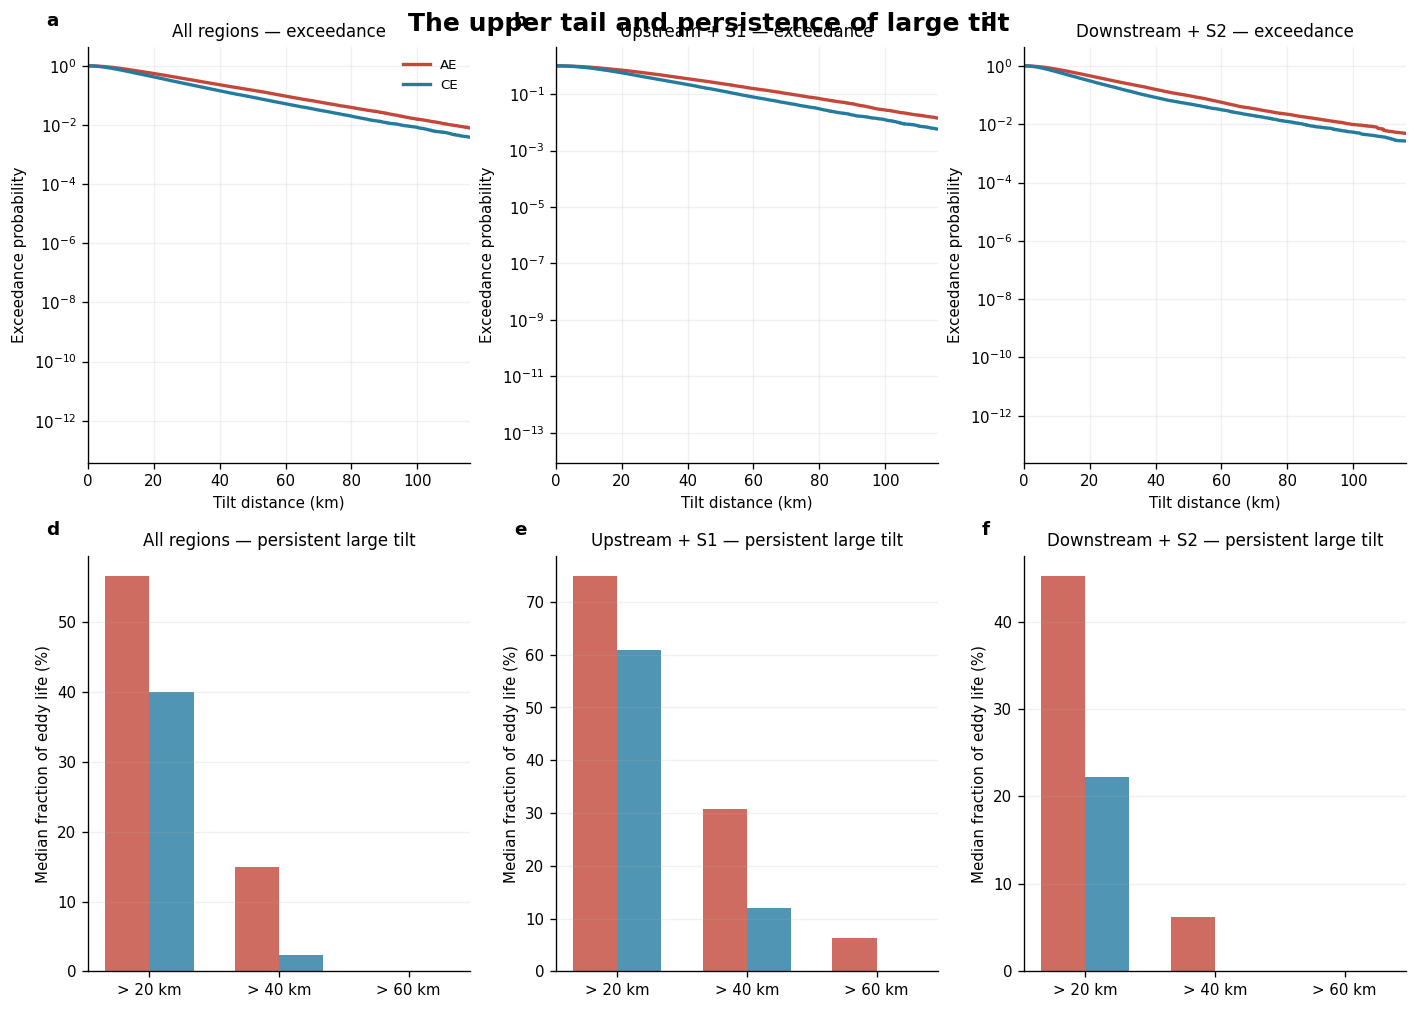

In [10]:
fig,axes=plt.subplots(2,3,figsize=PAGE_SIZE,constrained_layout=True)
subsets=[('All regions',tilt_data),('Upstream + S1',upstream),('Downstream + S2',downstream)]
for j,(label,g0) in enumerate(subsets):
    for cyc in ['AE','CE']:
        g=g0[g0.Cyc==cyc]; x,f=weighted_ecdf(g)
        axes[0,j].plot(x,1-f,color=TYPE_COLOURS[cyc],lw=2,label=cyc)
    axes[0,j].set(title=label+' — exceedance',xlabel='Tilt distance (km)',ylabel='Exceedance probability',yscale='log',xlim=(0,TILT_LIMIT)); axes[0,j].grid(alpha=.18)
    em=eddy_metrics(g0); thresholds=[20,40,60]
    frac=(g0.assign(over20=g0.TiltDis>=20,over40=g0.TiltDis>=40,over60=g0.TiltDis>=60)
          .groupby(KEYS)[['over20','over40','over60']].mean().reset_index())
    pos=np.arange(3); width=.34
    for k,cyc in enumerate(['AE','CE']):
        vals=frac[frac.Cyc==cyc][['over20','over40','over60']].median().to_numpy()*100
        axes[1,j].bar(pos+(k-.5)*width,vals,width,color=TYPE_COLOURS[cyc],alpha=.8,label=cyc)
    axes[1,j].set(title=label+' — persistent large tilt',xticks=pos,xticklabels=[f'> {t} km' for t in thresholds],ylabel='Median fraction of eddy life (%)'); axes[1,j].grid(axis='y',alpha=.18)
for i,ax in enumerate(axes.flat): panel_label(ax,chr(97+i))
axes[0,0].legend(frameon=False); finish_dashboard(fig,'08_extreme_tilt','The upper tail and persistence of large tilt')

## Dashboard 9 — Within-eddy variability census
Six one-value-per-eddy metrics describe typical magnitude, variability and extremes.

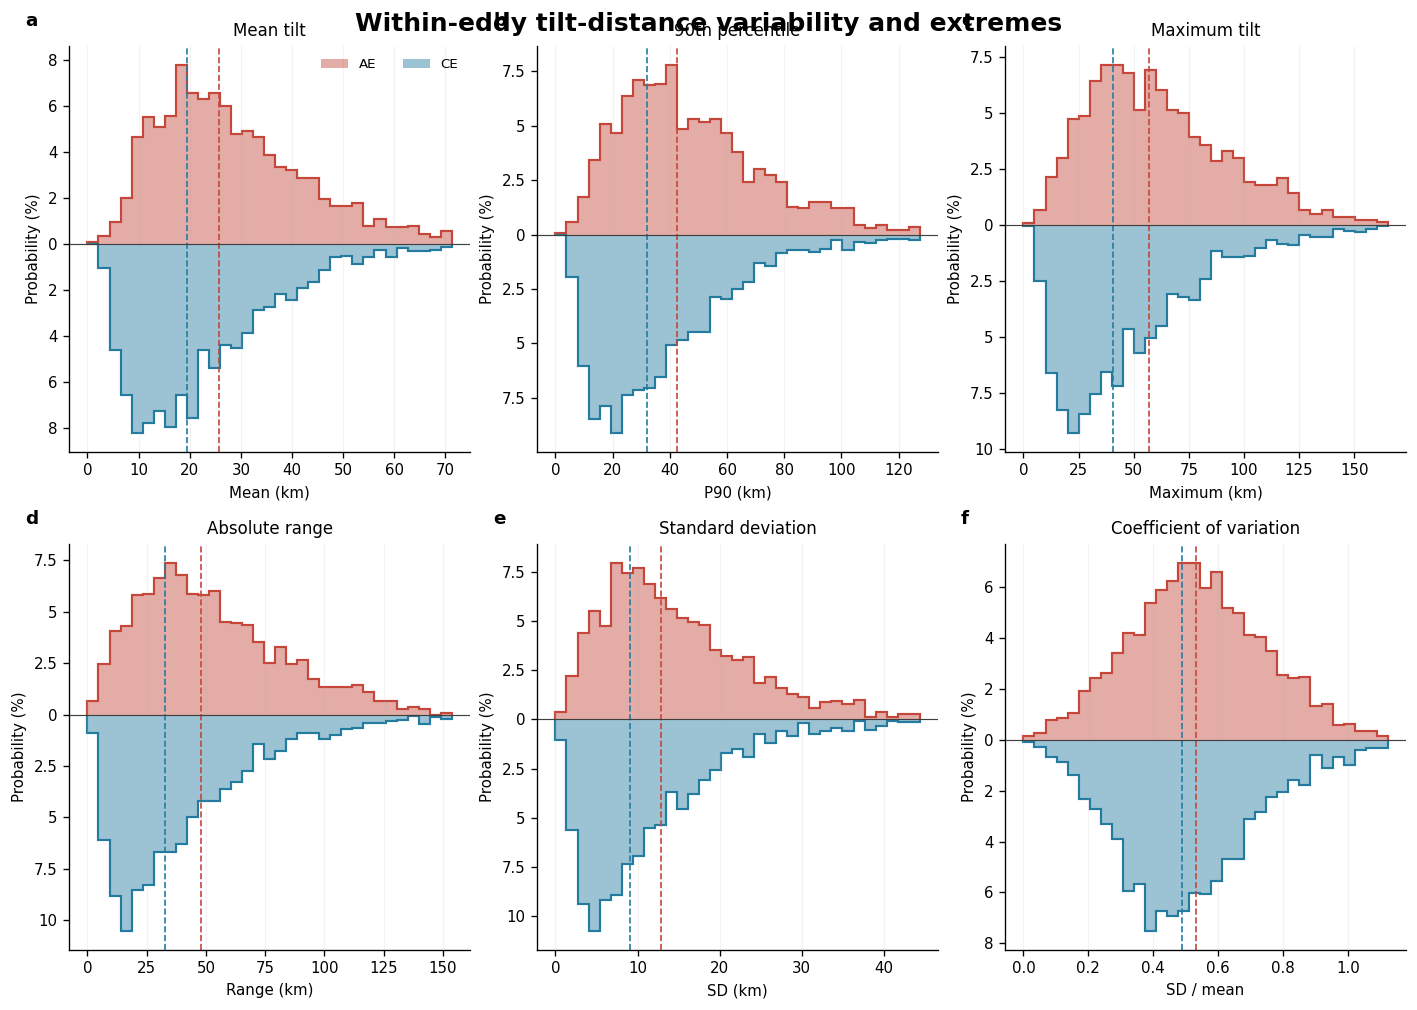

In [11]:
em=eddy_metrics(tilt_data); em['relative_range']=em['range']/em['mean']; em['cv']=em['std']/em['mean']
specs=[('mean','Mean tilt','Mean (km)'),('p90','90th percentile','P90 (km)'),('maximum','Maximum tilt','Maximum (km)'),
       ('range','Absolute range','Range (km)'),('std','Standard deviation','SD (km)'),('cv','Coefficient of variation','SD / mean')]
fig,axes=plt.subplots(2,3,figsize=PAGE_SIZE,constrained_layout=True)
for i,(ax,(col,title,xlab)) in enumerate(zip(axes.flat,specs)):
    mirrored_hist(ax,em,col,None,title,xlab); panel_label(ax,chr(97+i))
axes[0,0].legend(frameon=False,ncol=2); finish_dashboard(fig,'09_within_eddy_variability','Within-eddy tilt-distance variability and extremes')

## Dashboard 10 — Compact synthesis dashboard
A mixed-format summary intended as the strongest candidate for the paper.

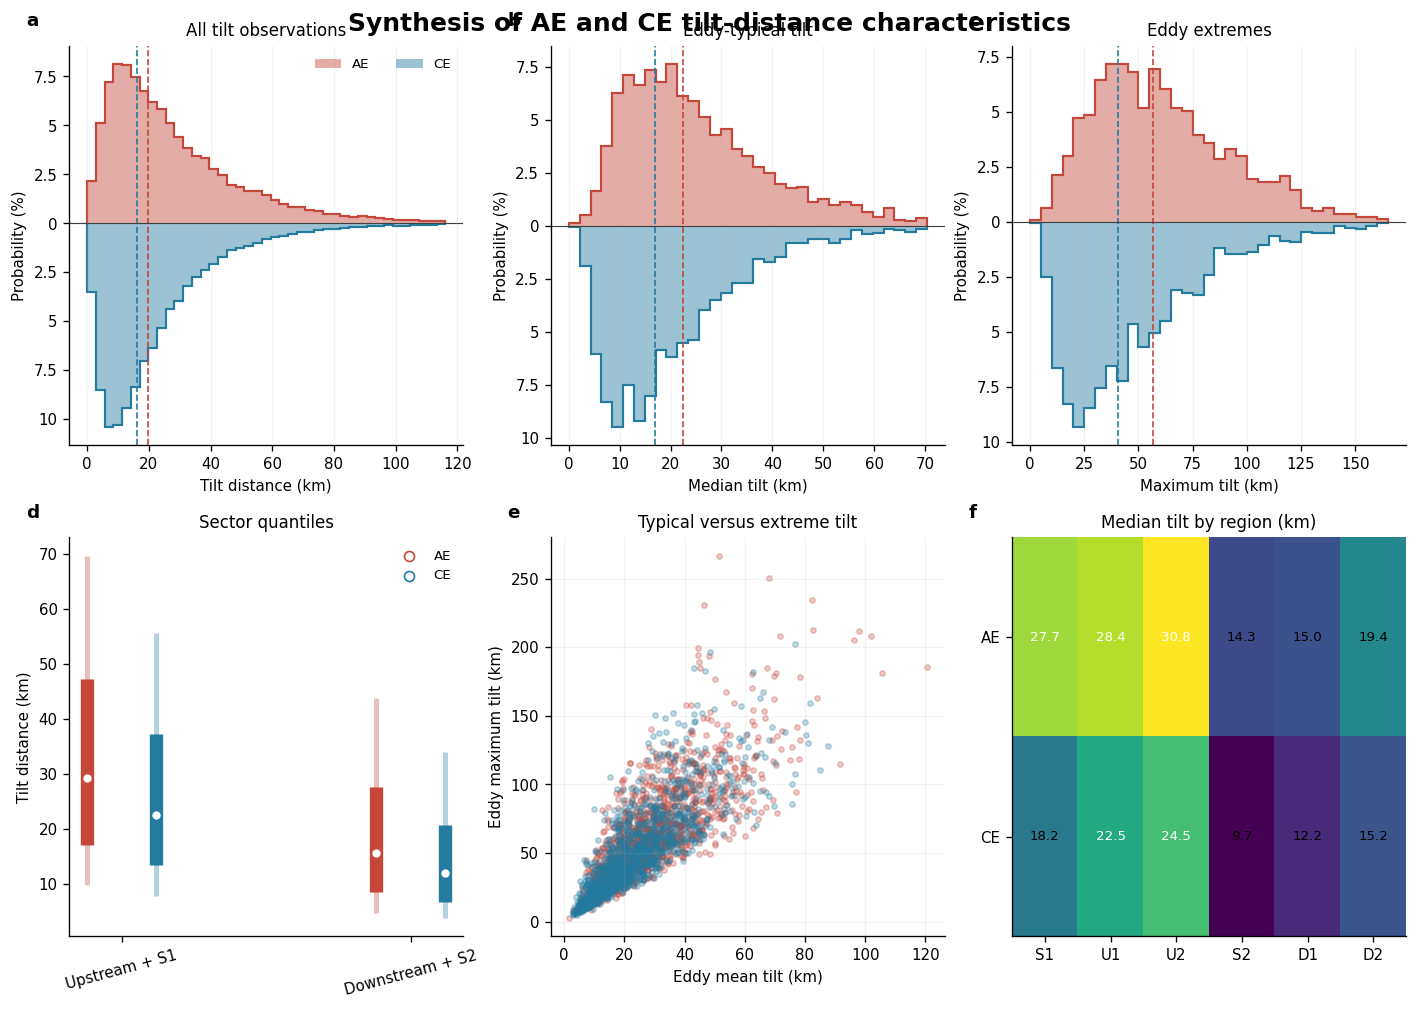

In [12]:
fig=plt.figure(figsize=PAGE_SIZE,constrained_layout=True); gs=fig.add_gridspec(2,3)
ax1=fig.add_subplot(gs[0,0]); ax2=fig.add_subplot(gs[0,1]); ax3=fig.add_subplot(gs[0,2]); ax4=fig.add_subplot(gs[1,0]); ax5=fig.add_subplot(gs[1,1]); ax6=fig.add_subplot(gs[1,2])
mirrored_hist(ax1,tilt_data,'TiltDis',TILT_BINS,'All tilt observations','Tilt distance (km)',True)
mirrored_hist(ax2,eddy_metrics(tilt_data),'median',None,'Eddy-typical tilt','Median tilt (km)')
mirrored_hist(ax3,eddy_metrics(tilt_data),'maximum',None,'Eddy extremes','Maximum tilt (km)')
q=grouped_quantiles(tilt_data.dropna(subset=['Sector']),'Sector'); x=np.arange(2)
for cyc,offset in [('AE',-.12),('CE',.12)]:
    s=q[q.Cyc==cyc].set_index('Sector').reindex(SECTOR_ORDER); ax4.vlines(x+offset,s[.1],s[.9],color=TYPE_COLOURS[cyc],alpha=.35,lw=3)
    ax4.vlines(x+offset,s[.25],s[.75],color=TYPE_COLOURS[cyc],lw=8); ax4.scatter(x+offset,s[.5],color='white',edgecolor=TYPE_COLOURS[cyc],zorder=3,label=cyc)
ax4.set(xticks=x,xticklabels=['Upstream + S1','Downstream + S2'],ylabel='Tilt distance (km)',title='Sector quantiles'); ax4.tick_params(axis='x',rotation=15); ax4.legend(frameon=False)
em=eddy_metrics(tilt_data)
for cyc in ['AE','CE']:
    g=em[em.Cyc==cyc]; ax5.scatter(g['mean'],g['maximum'],s=10,alpha=.28,color=TYPE_COLOURS[cyc],label=cyc)
ax5.set(xlabel='Eddy mean tilt (km)',ylabel='Eddy maximum tilt (km)',title='Typical versus extreme tilt'); ax5.grid(alpha=.15)
med=(tilt_data.groupby(['Region','Cyc']).TiltDis.median().unstack().reindex(SUBREGION_ORDER))
im=ax6.imshow(med.T,aspect='auto',cmap='viridis'); ax6.set(xticks=np.arange(6),xticklabels=SUBREGION_ORDER,yticks=[0,1],yticklabels=med.columns,title='Median tilt by region (km)')
for i in range(2):
    for j in range(6): ax6.text(j,i,f'{med.iloc[j,i]:.1f}',ha='center',va='center',color=('white' if med.iloc[j,i]>med.to_numpy().mean() else 'black'),fontsize=8)
for i,ax in enumerate([ax1,ax2,ax3,ax4,ax5,ax6]): panel_label(ax,chr(97+i))
ax1.legend(frameon=False,ncol=2); finish_dashboard(fig,'10_compact_synthesis','Synthesis of AE and CE tilt-distance characteristics')

## Suggested selection

Dashboard 10 is the strongest mixed-format summary candidate. Dashboards 1–3 retain the visual language of the original census and make the geographic contrast especially transparent. Dashboard 5 is useful if the six named regions are central to the paper, while Dashboard 8 is useful if large-tilt events are scientifically important.

Before submission, add eddy-level bootstrap confidence intervals to the final selected dashboard and rerun with the journal's exact page dimensions.